In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os

print(os.listdir())

['.config', 'web_traffic.csv', 'sample_data']


In [3]:
df = pd.read_csv("web_traffic.csv")

In [4]:
df.head()

,Timestamp,TrafficCount
0,2020-01-20 00:00:00,487.0
1,2020-01-20 00:30:00,385.0
2,2020-01-20 01:30:00,269.0
3,2020-01-20 02:30:00,517.0
4,2020-01-20 03:30:00,129.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2793 entries, 0 to 2792
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Timestamp     2793 non-null   object 
 1   TrafficCount  2793 non-null   float64
dtypes: float64(1), object(1)
memory usage: 43.8+ KB


In [6]:
df.describe()

,TrafficCount
count,2793.000000
mean,8591.321160
std,11478.605594
min,22.000000
25%,713.000000
50%,2418.000000
75%,14356.000000
max,71925.000000


In [7]:
df.isnull().sum()

,0
Timestamp,0
TrafficCount,0


In [8]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2793 entries, 0 to 2792
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Timestamp     2793 non-null   datetime64[ns]
 1   TrafficCount  2793 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 43.8 KB


In [10]:
df["Year"] = df["Timestamp"].dt.year
df["Month"] = df["Timestamp"].dt.month
df["Day"] = df["Timestamp"].dt.day
df["Hour"] = df["Timestamp"].dt.hour
df["DayOfWeek"] = df["Timestamp"].dt.day_name()

In [11]:
df.head()

,Timestamp,TrafficCount,Year,Month,Day,Hour,DayOfWeek
0,2020-01-20 00:00:00,487.0,2020,1,20,0,Monday
1,2020-01-20 00:30:00,385.0,2020,1,20,0,Monday
2,2020-01-20 01:30:00,269.0,2020,1,20,1,Monday
3,2020-01-20 02:30:00,517.0,2020,1,20,2,Monday
4,2020-01-20 03:30:00,129.0,2020,1,20,3,Monday


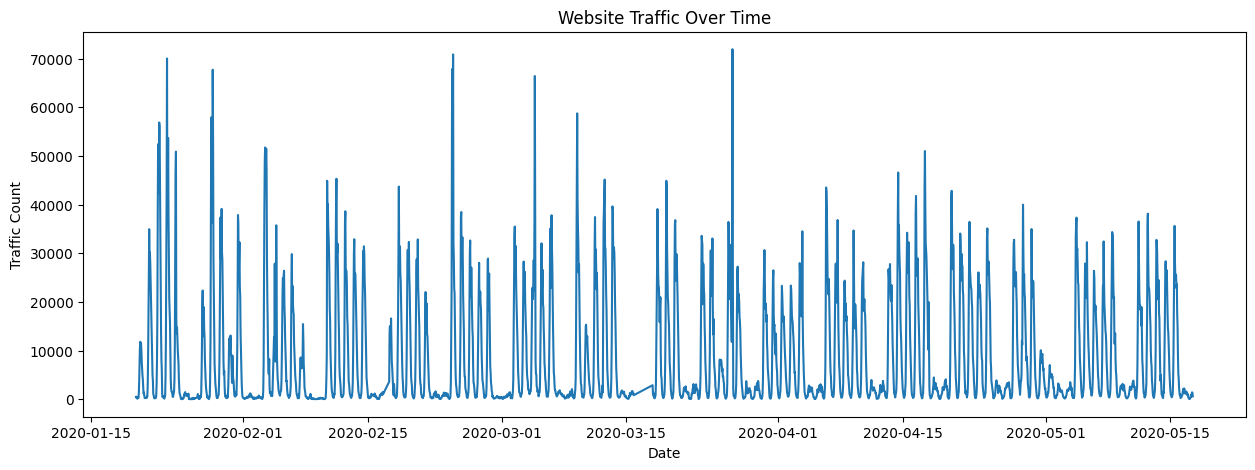

In [12]:
plt.figure(figsize=(15,5))
plt.plot(df["Timestamp"], df["TrafficCount"])
plt.title("Website Traffic Over Time")
plt.xlabel("Date")
plt.ylabel("Traffic Count")
plt.show()

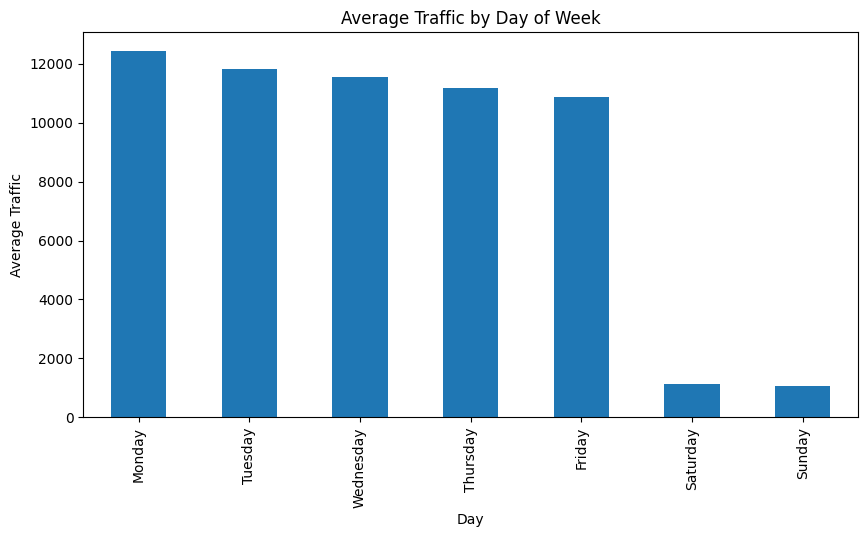

In [14]:
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

daily_traffic = df.groupby("DayOfWeek")["TrafficCount"].mean().reindex(day_order)

plt.figure(figsize=(10,5))
daily_traffic.plot(kind="bar")
plt.title("Average Traffic by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Traffic")
plt.show()

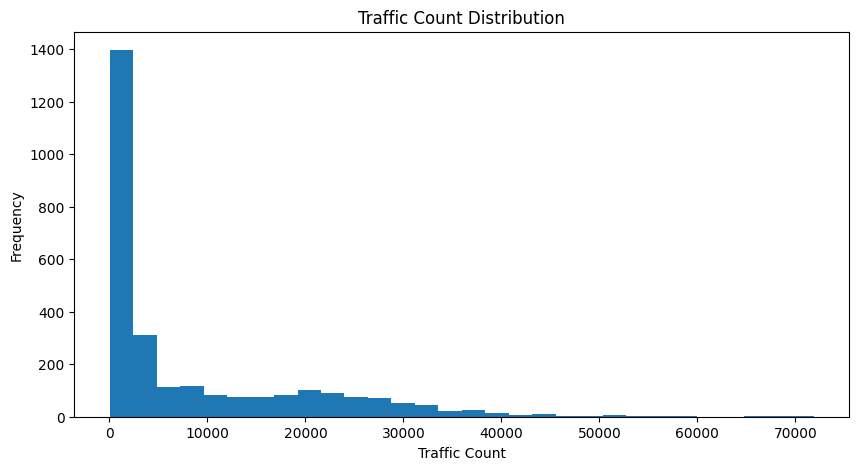

In [15]:
plt.figure(figsize=(10,5))
plt.hist(df["TrafficCount"], bins=30)
plt.title("Traffic Count Distribution")
plt.xlabel("Traffic Count")
plt.ylabel("Frequency")
plt.show()

In [16]:
df["DayNumber"] = df["Timestamp"].dt.dayofweek

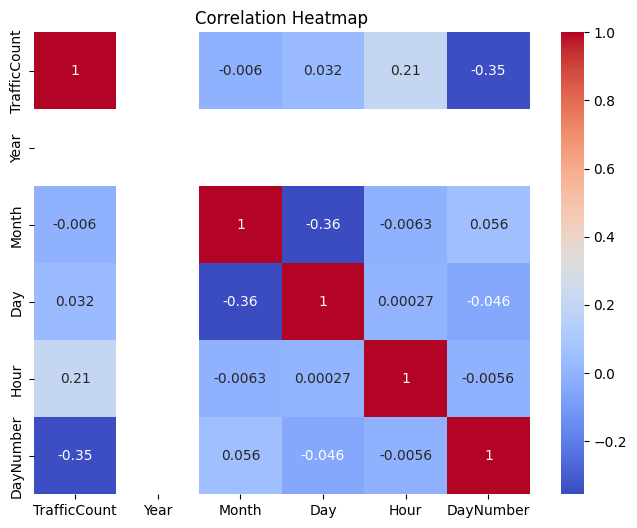

In [17]:
numeric_df = df[["TrafficCount","Year","Month","Day","Hour","DayNumber"]]

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [18]:
X = df[["Year", "Month", "Day", "Hour", "DayNumber"]]
y = df["TrafficCount"]

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [20]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (2234, 5)
Testing data: (559, 5)


In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [22]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [23]:
lr_predictions = lr_model.predict(X_test)

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, lr_predictions)
mse = mean_squared_error(y_test, lr_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, lr_predictions)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

Mean Absolute Error: 7400.430214480616
Mean Squared Error: 100752658.98053944
Root Mean Squared Error: 10037.562402323556
R2 Score: 0.19756065042194282


In [25]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [26]:
rf_predictions = rf_model.predict(X_test)

In [27]:
mae_rf = mean_absolute_error(y_test, rf_predictions)
mse_rf = mean_squared_error(y_test, rf_predictions)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, rf_predictions)

print("Random Forest Results")
print("----------------------")
print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest Results
----------------------
MAE: 1877.49560405486
MSE: 18093430.43511544
RMSE: 4253.637318238996
R2 Score: 0.8558958076451937


In [28]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, mae_rf],
    "RMSE": [rmse, rmse_rf],
    "R2 Score": [r2, r2_rf]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,7400.430214,10037.562402,0.197561
1,Random Forest,1877.495604,4253.637318,0.855896


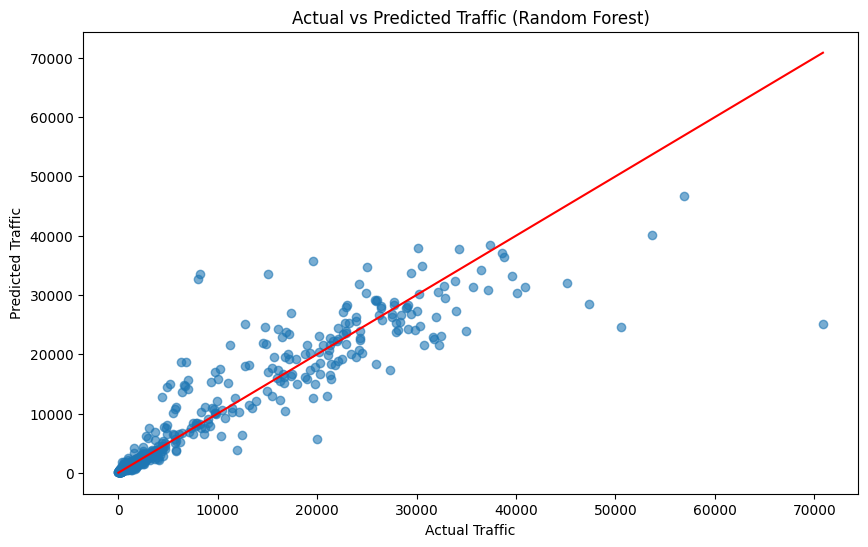

In [29]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, rf_predictions, alpha=0.6)
plt.xlabel("Actual Traffic")
plt.ylabel("Predicted Traffic")
plt.title("Actual vs Predicted Traffic (Random Forest)")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)
plt.show()

In [30]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
3,Hour,0.564052
4,DayNumber,0.286523
2,Day,0.103097
1,Month,0.046327
0,Year,0.000000


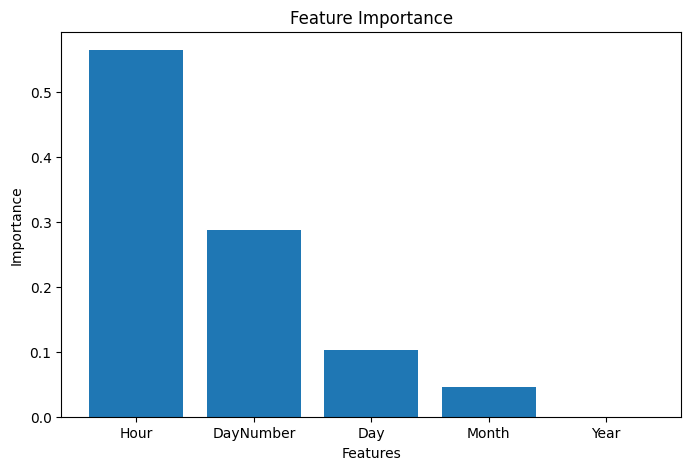

In [31]:
plt.figure(figsize=(8,5))
plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

In [32]:
df.to_csv("cleaned_web_traffic.csv", index=False)

# Conclusion

In this project, a complete Machine Learning pipeline was developed to analyze and predict website traffic.

The dataset was cleaned and explored using exploratory data analysis (EDA). Several new features such as Year, Month, Day, Hour, and Day of Week were extracted from the timestamp to improve prediction performance.

Two machine learning models were trained:

- Linear Regression
- Random Forest Regression

After evaluating both models using MAE, RMSE, and R² Score, the Random Forest model performed significantly better.

The Random Forest model achieved an R² Score of approximately 0.856, indicating that it can explain about 85.6% of the variation in website traffic.

Therefore, Random Forest was selected as the best model for predicting web traffic.